In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
CSV_PATH = "dataset_as03.csv"   

df = pd.read_csv(CSV_PATH)

# Replace SQL-style missing marker "\N" with NaN
df = df.replace(r"\N", np.nan)

# Parse timestamp (the assignment uses `name` as timestamp, format yyyymmddhhmm) :contentReference[oaicite:1]{index=1}
df["time"] = pd.to_datetime(df["name"].astype(str), format="%Y%m%d%H%M", errors="coerce")
df = df.sort_values("time").reset_index(drop=True)

In [3]:
# Convert all non-time columns to numeric where possible
for c in df.columns:
    if c not in ["name", "time"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("Rows:", len(df))
print("Time range:", df["time"].min(), "→", df["time"].max())

Rows: 12084
Time range: 2015-09-07 11:00:00 → 2015-11-30 23:50:00


In [4]:
def plot_timeseries_group(df_plot: pd.DataFrame, cols: list[str], title: str, ylabel: str):
   
    plt.figure(figsize=(12, 4))
    labels = ["Mean", "Min", "Max", "Stdv"]
    for col, lab in zip(cols, labels):
        if col in df_plot.columns:
            plt.plot(df_plot["time"], df_plot[col], label=f"{lab} ({col})", linewidth=0.9)

    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()


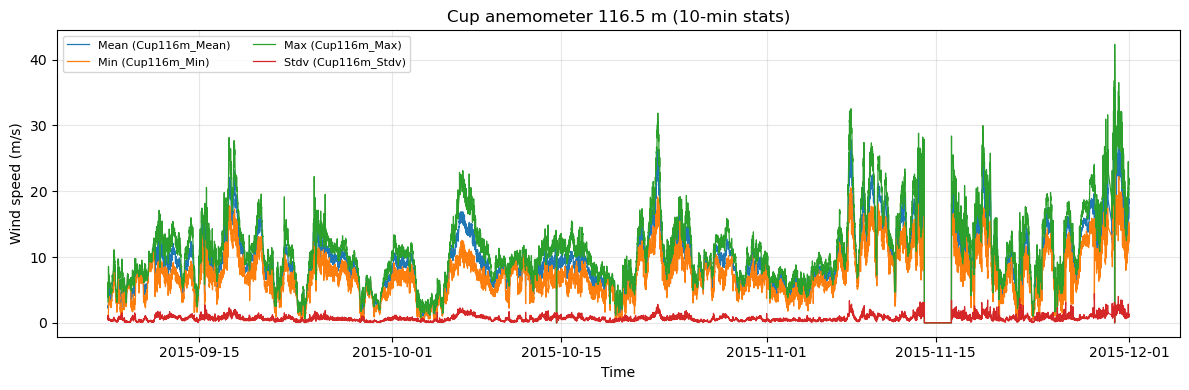

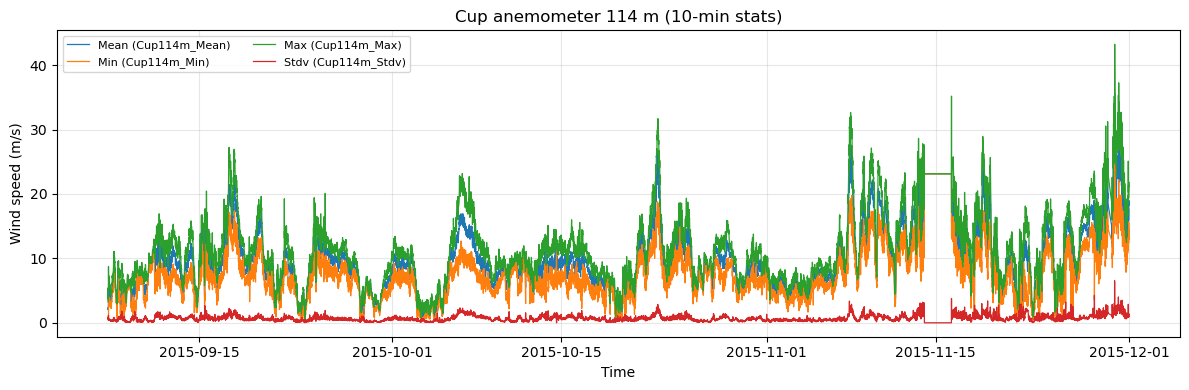

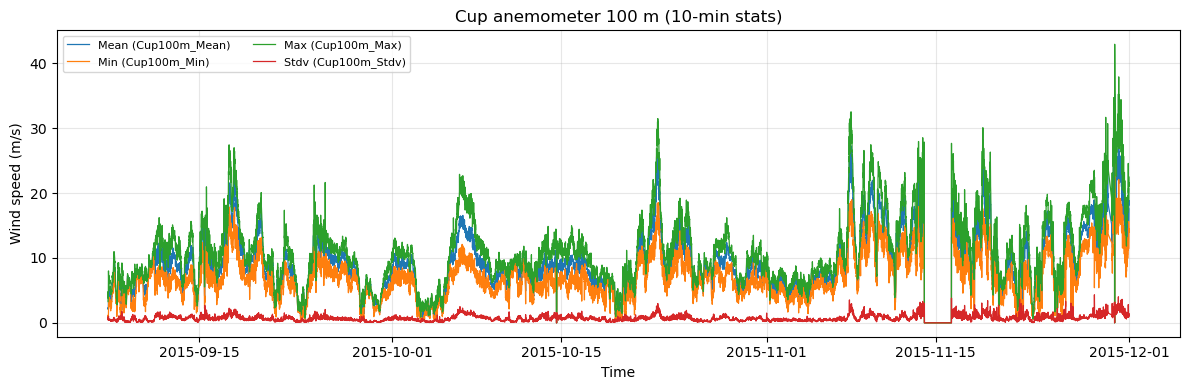

In [5]:
plot_timeseries_group(
    df,
    ["Cup116m_Mean", "Cup116m_Min", "Cup116m_Max", "Cup116m_Stdv"],
    "Cup anemometer 116.5 m (10-min stats)",
    "Wind speed (m/s)",
)
plot_timeseries_group(
    df,
    ["Cup114m_Mean", "Cup114m_Min", "Cup114m_Max", "Cup114m_Stdv"],
    "Cup anemometer 114 m (10-min stats)",
    "Wind speed (m/s)",
)
plot_timeseries_group(
    df,
    ["Cup100m_Mean", "Cup100m_Min", "Cup100m_Max", "Cup100m_Stdv"],
    "Cup anemometer 100 m (10-min stats)",
    "Wind speed (m/s)",
)

In [6]:
# ----------------------------
# QC CONDITIONS + APPLY (set NaN)
# ----------------------------

def minmax_mean_std_mask(df, prefix):
    """Generic consistency + dropout checks for *_Mean/_Min/_Max/_Stdv."""
    m = pd.Series(False, index=df.index)

    mu = f"{prefix}_Mean"
    mn = f"{prefix}_Min"
    mx = f"{prefix}_Max"
    sd = f"{prefix}_Stdv"

    # min/max consistency
    if mn in df.columns and mx in df.columns:
        m |= (df[mn] > df[mx])

    # mean must lie between min and max (if available)
    if mu in df.columns and mn in df.columns and mx in df.columns:
        m |= (df[mu] < df[mn]) | (df[mu] > df[mx])

    # stdv must be non-negative
    if sd in df.columns:
        m |= (df[sd] < 0)

    # dropout: all stats exactly zero (only if all exist)
    if all(c in df.columns for c in [mu, mn, mx, sd]):
        m |= (df[mu] == 0) & (df[mn] == 0) & (df[mx] == 0) & (df[sd] == 0)

    return m


def build_qc_masks(df):
    masks = {}

    # ---- Cups (m/s) ----
    cups_bad = pd.Series(False, index=df.index)
    for p in ["Cup100m", "Cup114m", "Cup116m"]:
        mu = f"{p}_Mean"
        sd = f"{p}_Stdv"

        if mu in df.columns:
            cups_bad |= (df[mu] < 0) | (df[mu] > 60)
        if sd in df.columns:
            cups_bad |= (df[sd] > 15)

        cups_bad |= minmax_mean_std_mask(df, p)

    masks["cups"] = cups_bad

    # ---- Sonic speeds (m/s) ----
    sonic_bad = pd.Series(False, index=df.index)
    for p in ["Sonic100m_Scalar", "Sonic100m_Vector"]:
        mu = f"{p}_Mean"
        sd = f"{p}_Stdv"

        if mu in df.columns:
            sonic_bad |= (df[mu] < 0) | (df[mu] > 60)
        if sd in df.columns:
            sonic_bad |= (df[sd] > 15)

        sonic_bad |= minmax_mean_std_mask(df, p)

    # Sonic direction (deg)
    if "Sonic100m_Dir" in df.columns:
        sonic_bad |= (df["Sonic100m_Dir"] < 0) | (df["Sonic100m_Dir"] >= 360)
        sonic_bad |= (df["Sonic100m_Dir"] == 0)  # dropout segments visible in your plot

    masks["sonic"] = sonic_bad

    # ---- Vane direction (deg) ----
    vane_bad = pd.Series(False, index=df.index)

    for c in ["Vane100m_Mean", "Vane100m_Min", "Vane100m_Max"]:
        if c in df.columns:
            vane_bad |= (df[c] < 0) | (df[c] >= 360)
            vane_bad |= (df[c] == 0)  # dropout segments visible in your plot

    if "Vane100m_Stdv" in df.columns:
        vane_bad |= (df["Vane100m_Stdv"] < 0) | (df["Vane100m_Stdv"] > 120)

    if "Vane100m_Min" in df.columns and "Vane100m_Max" in df.columns:
        vane_bad |= (df["Vane100m_Min"] > df["Vane100m_Max"])

    masks["vane"] = vane_bad

    # ---- Temperature (°C) ----
    temp_bad = pd.Series(False, index=df.index)

    # Physical plausible bounds
    for c in ["Temp100m_Mean", "Temp100m_Min", "Temp100m_Max"]:
        if c in df.columns:
            temp_bad |= (df[c] < -40) | (df[c] > 45)

    # Std deviation sanity (too large variability is suspicious)
    if "Temp100m_Stdv" in df.columns:
        temp_bad |= (df["Temp100m_Stdv"] < 0) | (df["Temp100m_Stdv"] > 5)

    # Min/Max consistency
    if "Temp100m_Min" in df.columns and "Temp100m_Max" in df.columns:
        temp_bad |= (df["Temp100m_Min"] > df["Temp100m_Max"])

    # Mean must lie within [Min, Max]
    if all(c in df.columns for c in ["Temp100m_Mean", "Temp100m_Min", "Temp100m_Max"]):
        temp_bad |= (df["Temp100m_Mean"] < df["Temp100m_Min"]) | (df["Temp100m_Mean"] > df["Temp100m_Max"])

    # Sudden unrealistic 10-min jumps/dips → invalidate the whole record
    

    JUMP_T_MEAN = 4.0
    JUMP_T_MIN  = 5.0
    JUMP_T_MAX  = 5.0
    JUMP_T_STDV = 2.0

    if "Temp100m_Mean" in df.columns:
        temp_bad |= df["Temp100m_Mean"].diff().abs() > JUMP_T_MEAN

    if "Temp100m_Min" in df.columns:
        temp_bad |= df["Temp100m_Min"].diff().abs() > JUMP_T_MIN

    if "Temp100m_Max" in df.columns:
        temp_bad |= df["Temp100m_Max"].diff().abs() > JUMP_T_MAX
    
    if "Temp100m_Stdv" in df.columns:
        temp_bad |= df["Temp100m_Stdv"].diff().abs() > JUMP_T_STDV
    
    masks["temp"] = temp_bad

    return masks


def apply_mask_to_columns(df_clean, mask, columns):
    """Set df_clean[columns] = NaN where mask is True."""
    cols = [c for c in columns if c in df_clean.columns]
    df_clean.loc[mask, cols] = np.nan





In [7]:
# 1) Build masks
masks = build_qc_masks(df)

print("Bad rows flagged:")
for k, m in masks.items():
    print(f"  {k}: {int(m.sum())} rows")

# 2) Apply to a cleaned copy
df_qc = df.copy()

# Define column groups to blank out when that group's mask is True
cup_cols = [
    "Cup100m_Mean","Cup100m_Min","Cup100m_Max","Cup100m_Stdv",
    "Cup114m_Mean","Cup114m_Min","Cup114m_Max","Cup114m_Stdv",
    "Cup116m_Mean","Cup116m_Min","Cup116m_Max","Cup116m_Stdv",
]
sonic_cols = [
    "Sonic100m_Scalar_Mean","Sonic100m_Scalar_Min","Sonic100m_Scalar_Max","Sonic100m_Scalar_Stdv",
    "Sonic100m_Vector_Mean","Sonic100m_Vector_Min","Sonic100m_Vector_Max","Sonic100m_Vector_Stdv",
    "Sonic100m_Dir"
]
vane_cols = ["Vane100m_Mean","Vane100m_Min","Vane100m_Max","Vane100m_Stdv"]
temp_cols = ["Temp100m_Mean","Temp100m_Min","Temp100m_Max","Temp100m_Stdv"]

apply_mask_to_columns(df_qc, masks["cups"],  cup_cols)
apply_mask_to_columns(df_qc, masks["sonic"], sonic_cols)
apply_mask_to_columns(df_qc, masks["vane"],  vane_cols)
apply_mask_to_columns(df_qc, masks["temp"],  temp_cols)


Bad rows flagged:
  cups: 329 rows
  sonic: 383 rows
  vane: 351 rows
  temp: 24 rows


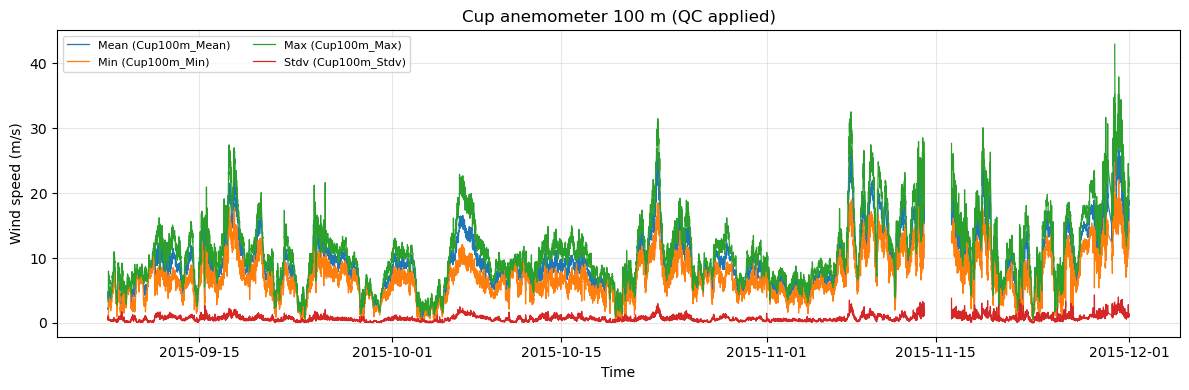

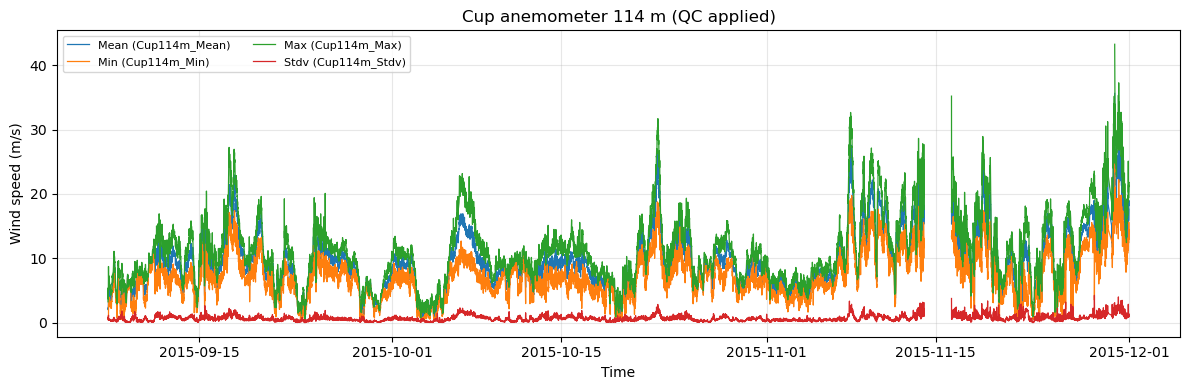

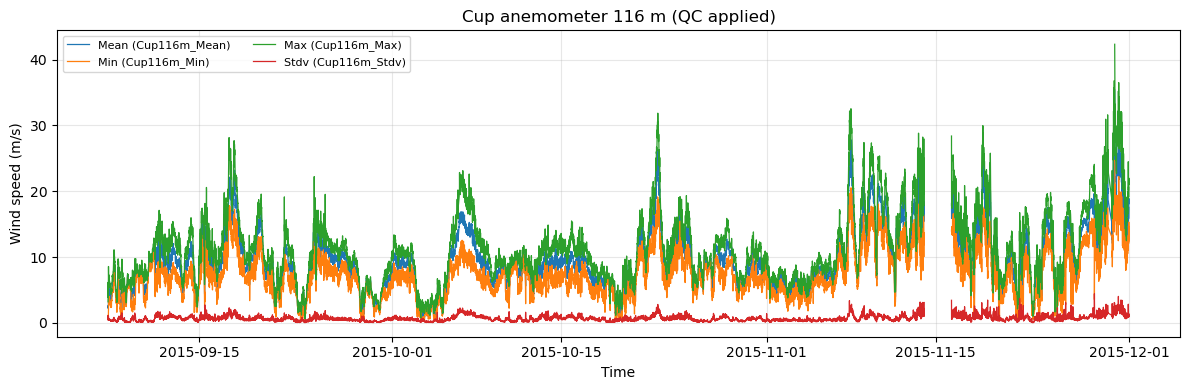

In [8]:
plot_timeseries_group(
    df_qc,
    ["Cup100m_Mean", "Cup100m_Min", "Cup100m_Max", "Cup100m_Stdv"],
    "Cup anemometer 100 m (QC applied)",
    "Wind speed (m/s)",
)

plot_timeseries_group(
    df_qc,
    ["Cup114m_Mean", "Cup114m_Min", "Cup114m_Max", "Cup114m_Stdv"],
    "Cup anemometer 114 m (QC applied)",
    "Wind speed (m/s)",
)

plot_timeseries_group(
    df_qc,
    ["Cup116m_Mean", "Cup116m_Min", "Cup116m_Max", "Cup116m_Stdv"],
    "Cup anemometer 116 m (QC applied)",
    "Wind speed (m/s)",
)

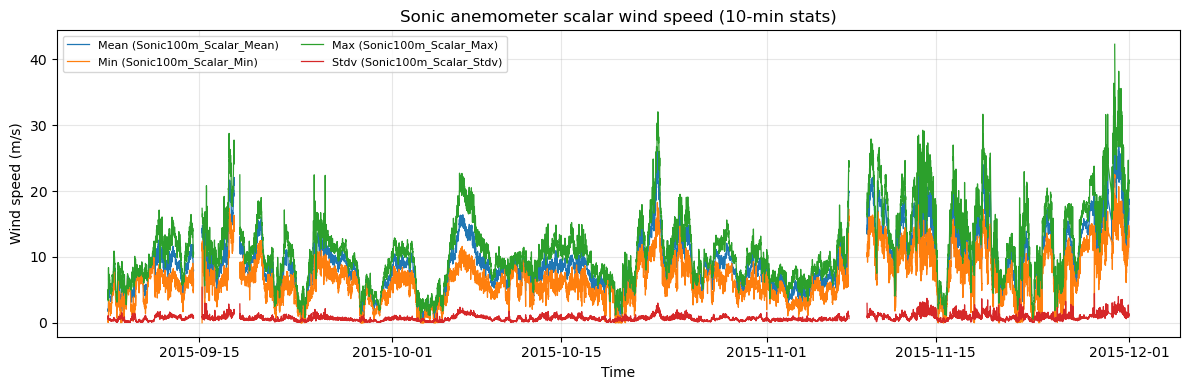

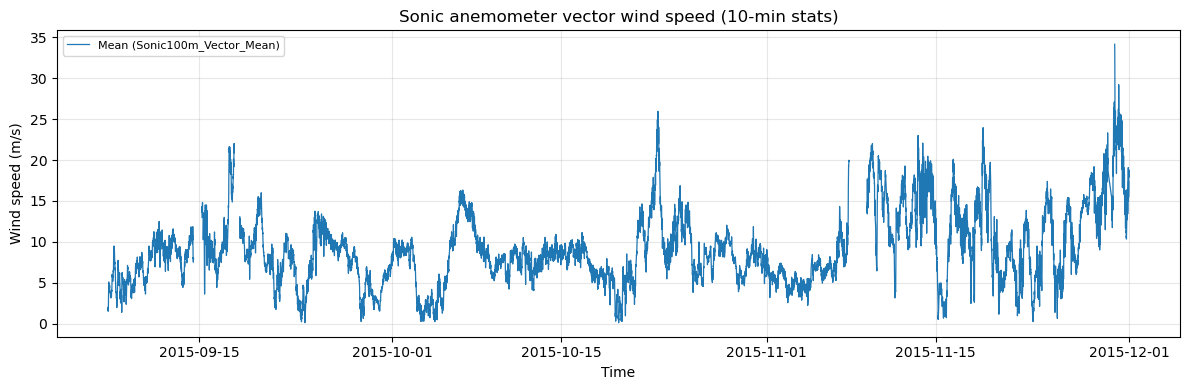

In [9]:
plot_timeseries_group(
    df_qc,
    ["Sonic100m_Scalar_Mean", "Sonic100m_Scalar_Min", "Sonic100m_Scalar_Max", "Sonic100m_Scalar_Stdv"],
    "Sonic anemometer scalar wind speed (10-min stats)",
    "Wind speed (m/s)",
)

plot_timeseries_group(
    df_qc,
    ["Sonic100m_Vector_Mean"],
    "Sonic anemometer vector wind speed (10-min stats)",
    "Wind speed (m/s)",
)

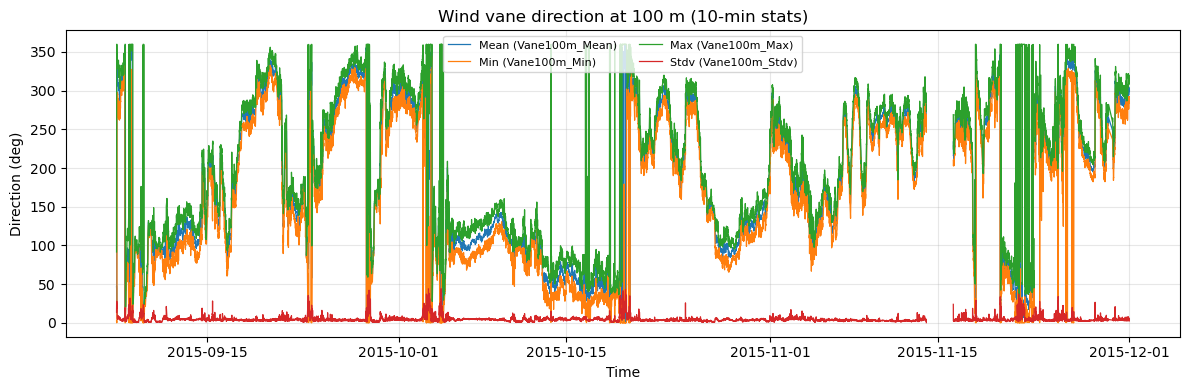

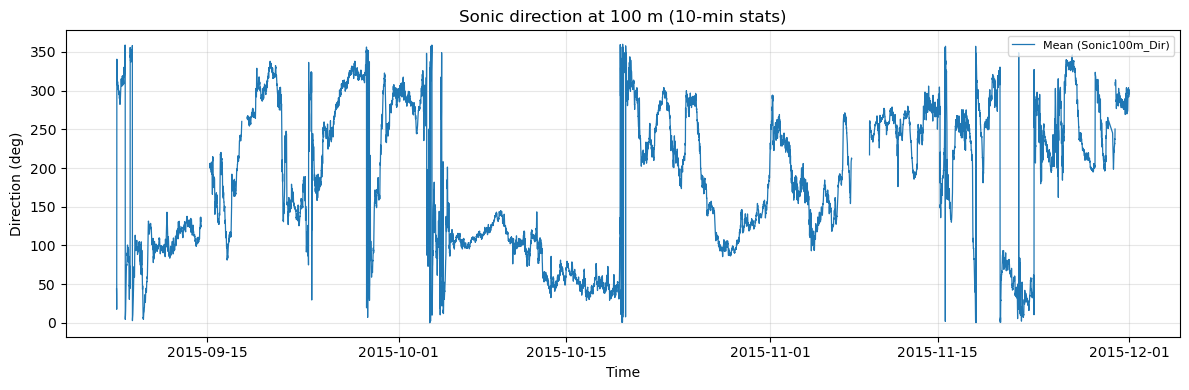

In [10]:
plot_timeseries_group(
    df_qc,
    ["Vane100m_Mean", "Vane100m_Min", "Vane100m_Max", "Vane100m_Stdv"],
    "Wind vane direction at 100 m (10-min stats)",
    "Direction (deg)",
)

plot_timeseries_group(
    df_qc,
    ["Sonic100m_Dir"],
    "Sonic direction at 100 m (10-min stats)",
    "Direction (deg)",
)



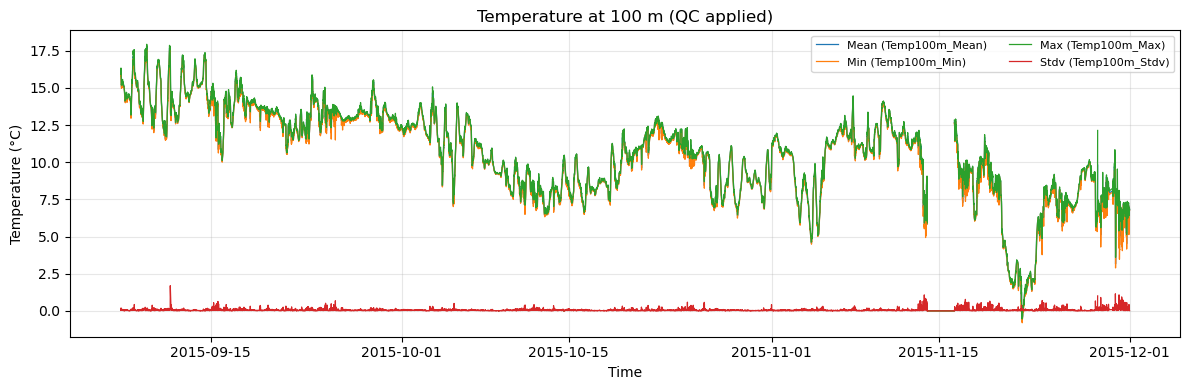

In [11]:
plot_timeseries_group(
    df_qc,
    ["Temp100m_Mean", "Temp100m_Min", "Temp100m_Max", "Temp100m_Stdv"],
    "Temperature at 100 m (QC applied)",
    "Temperature (°C)",
)

Scatter plot to first investigate Windcube (see AS02_dataset_description for further info) and cup anemometer (the one placed at 100 m to have homogeneous heights) wind speeds measurements.

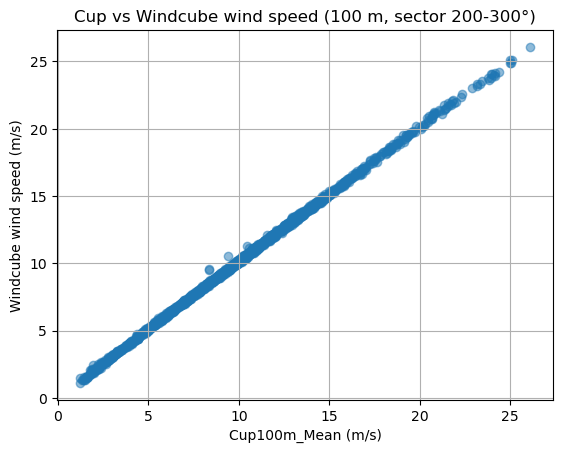

Original points: 12084
Sector points: 1904


In [12]:
sector_mask = ((df_qc["Vane100m_Mean"] >= 200) & (df_qc["Vane100m_Mean"] <= 300))
df_sector = df_qc[sector_mask].copy()

#drop NaNs values otherwise library for linear regression will complain
df_sector = df_sector[[
    "Cup100m_Mean",
    "Spd"
]].dropna()

plt.figure()
plt.scatter(df_sector["Cup100m_Mean"], df_sector["Spd"], alpha=0.5)
plt.title("Cup vs Windcube wind speed (100 m, sector 200-300°)")
plt.xlabel("Cup100m_Mean (m/s)")
plt.ylabel("Windcube wind speed (m/s)")
plt.grid(True)
plt.show()

print("Original points:", len(df_qc))
print("Sector points:", len(df_sector))

Linear regression of lidar (Windcube) as function of cup anemometer (mounted at 100m) wind speed. Import first the library and then carry out the regression.

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
X = df_sector["Cup100m_Mean"].values.reshape(-1,1)
y = df_sector["Spd"].values

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X, y)

print("Gain:", slope)
print("Offset:", intercept)
print("R2:", r2)

Gain: 1.004249686222502
Offset: 0.09727256679405727
R2: 0.9994430634117669


Scatter plot for availability without any availability filter (even 10 minutes data measurement bins with less than 100% availability are included).

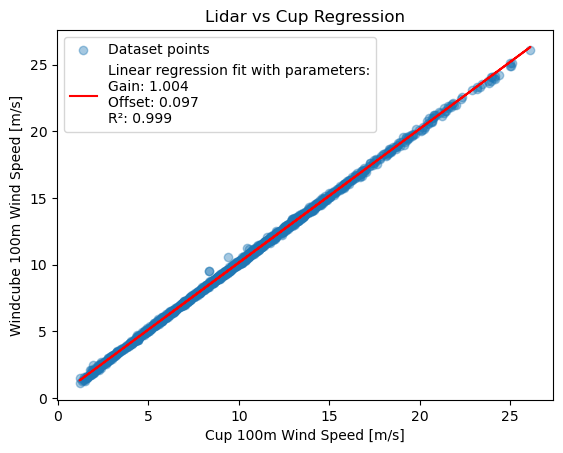

In [15]:
plt.figure()
plt.scatter(X, y, alpha=0.4)
plt.plot(X, model.predict(X), color="red")
plt.xlabel("Cup 100m Wind Speed [m/s]")
plt.ylabel("Windcube 100m Wind Speed [m/s]")
plt.title("Lidar vs Cup Regression")
plt.legend(["Dataset points", "Linear regression fit with parameters:\n"
            f"Gain: {slope:.3f}\nOffset: {intercept:.3f}\nR²: {r2:.3f}"])
plt.show()

Availability filters are now set and new linear regressions are carried out to see the differences.

In [16]:
def availability_filter(df, availability):

    sector_mask = ((df["Vane100m_Mean"] >= 200) & (df["Vane100m_Mean"] <= 300))
    df_sector = df[sector_mask].copy()

    avail_mask = df_sector['Available'] >= availability
    df_avail = df_sector[avail_mask].copy()

    df_avail = df_avail[['Cup100m_Mean', 'Spd']].dropna()
    
    X = df_avail["Cup100m_Mean"].values.reshape(-1,1)
    y = df_avail["Spd"].values

    model = LinearRegression()
    model.fit(X, y)

    slope = model.coef_[0]
    intercept = model.intercept_
    r2 = model.score(X, y)

    print("Gain:", slope)
    print("Offset:", intercept)
    print("R2:", r2)

    plt.figure()
    plt.scatter(X, y, alpha=0.4)
    plt.plot(X, model.predict(X), color="red")
    plt.xlabel("Cup 100m Wind Speed [m/s]")
    plt.ylabel("Windcube 100m Wind Speed [m/s]")
    plt.title("Lidar vs Cup Regression")
    plt.legend([f"Dataset points (availability >= {availability})", "Linear regression fit with parameters:\n"
                f"Gain: {slope:.3f}\nOffset: {intercept:.3f}\nR²: {r2:.3f}"])
    plt.show()
    


--- Validity filter of Lidar's measurements: 100% ---
Gain: 1.0043064481088677
Offset: 0.09554212003148876
R2: 0.9994568211877987


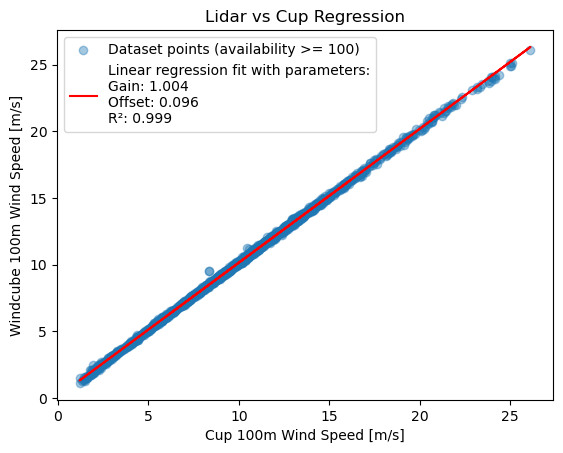


--- Validity filter of Lidar's measurements: 95% ---
Gain: 1.0042149199513621
Offset: 0.0975595579512536
R2: 0.9994406612230846


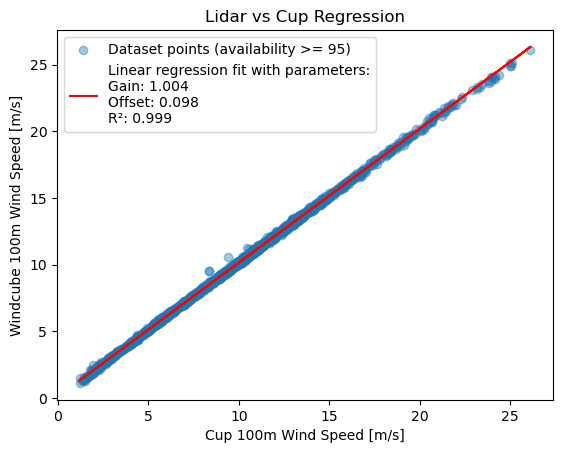


--- Validity filter of Lidar's measurements: 90% ---
Gain: 1.0042170826928218
Offset: 0.09772346063411597
R2: 0.9994420831260331


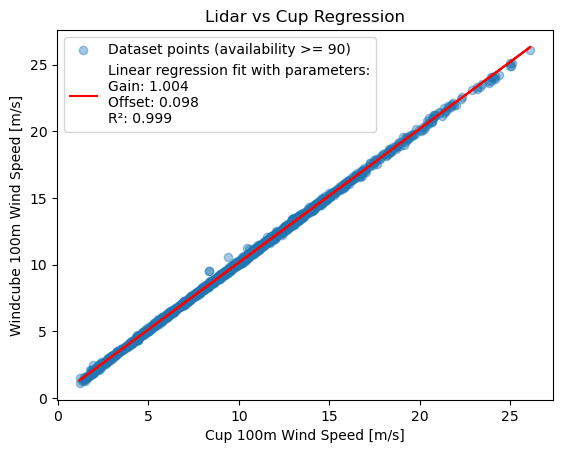


--- Validity filter of Lidar's measurements: 85% ---
Gain: 1.0042436522081029
Offset: 0.09737246199729022
R2: 0.9994430866172406


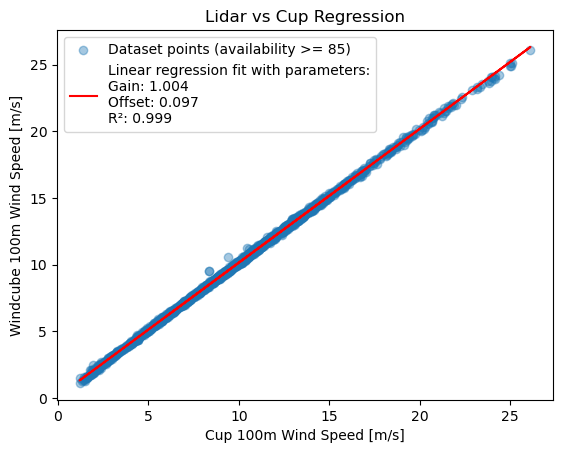


--- Validity filter of Lidar's measurements: 80% ---
Gain: 1.0042436522081029
Offset: 0.09737246199729022
R2: 0.9994430866172406


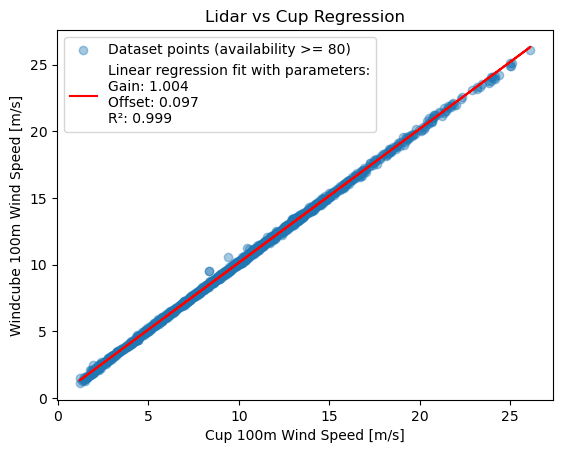

In [17]:
availability_values = [100, 95, 90, 85, 80]
for avail in availability_values:
    print(f"\n--- Validity filter of Lidar's measurements: {avail}% ---")
    availability_filter(df_qc, avail)

Part 5: filters for icing on cup anemometers cones. The idea to detect corrupted data measurements for such reason is the following: insert a mask that filters the dataset where the temperature is lower than 2 degrees (ice starts accumulating on cups at that temperature), cup anemometer wind speed is lower than 1 m/s (unlikely wind speed to happen) and, least but not last, ratio between cup anemometer and lidar wind speed is off (should maybe be supported by a linear regression to see how they are correlated).


In [ ]:
icing_mask = ( (df_qc['Temp100m_Mean'] < 1) & 
              ((df_qc['Cup100m_Mean']/df_qc['Sonic100m_Scalar_Mean']) < 0.90)
)

df.loc[icing_mask, 'Cup100m_Mean'] = np.nan

removed = icing_mask.sum()
print("Points removed due to icing:", removed)

Points removed due to icing: 0


To filter wind speed range for lidar calibration, since it's based on cup anemometer measurements, another mask can be applied filtering cup anemometer wind speeds between 4 m/s and 16 m/s and then deleting windcube's measurements corresponding to these velocities. That being, this is valid because below 4 m/s there is an higher uncertainty whereas measurements above 16 m/s are usually scarce and above rated wind speed thus negligible. 

In [19]:
speed_mask = (
    (df_qc["Cup100m_Mean"] >= 4) &
    (df_qc["Cup100m_Mean"] <= 16)
)

df_mask_for_lidar_calib = df_qc[speed_mask]